# 과제 1: 커널 비교 실험
## 유방암(Breast Cancer) 데이터를 사용해 SVM의 커널 종류를 바꿔가며 결과를 시각화하기

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn import svm
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'AppleGothic'  
plt.rcParams['axes.unicode_minus'] = False   

In [ ]:
cancer = load_breast_cancer()

In [ ]:
print(cancer.target_names)   

['malignant' 'benign']


In [ ]:
X, y = cancer.data[:, :2], cancer.target

In [ ]:
X_train, X_test, y_train, y_test =  train_test_split (X,y,test_size=0.2, random_state=42)

In [ ]:
X.shape

(569, 2)

In [ ]:
y.shape

(569,)

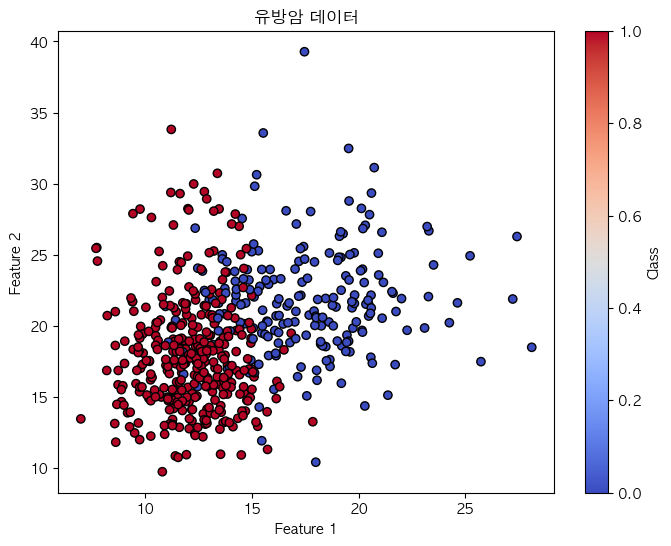

In [ ]:
# 데이터 시각화
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='black')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('유방암 데이터')
plt.colorbar(label='Class')
plt.show()

## 1) linear (선형 커널)

In [ ]:
# Linear Kernel SVM 생성 및 학습
clf_linear = svm.SVC(kernel='linear', C=1.0)
clf_linear.fit(X, y)

SVC(kernel='linear')

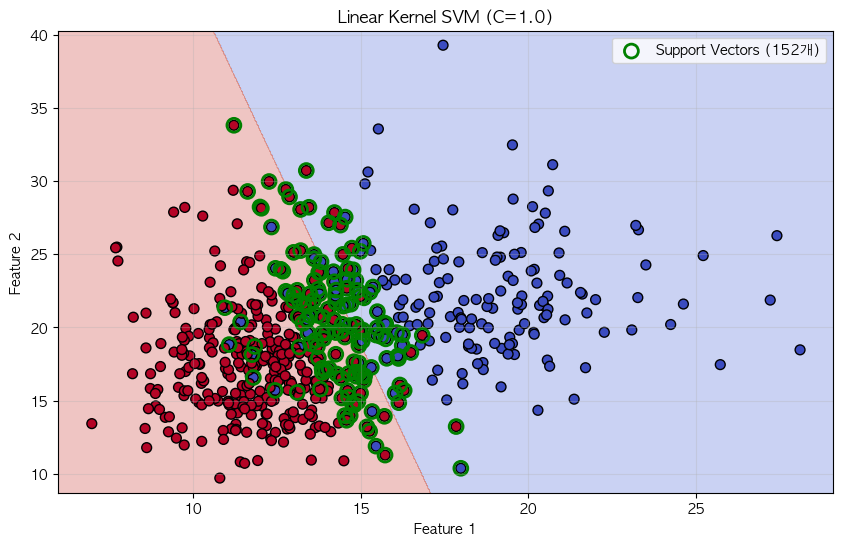

In [ ]:
def plot_decision_boundary(clf, X, y, title):
    """SVM 결정 경계를 시각화하는 함수"""
    
    # 메쉬 그리드 생성을 위한 범위 설정
    h = .02  # 메쉬 간격
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    # 메쉬 그리드 생성
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                        np.arange(y_min, y_max, h))
    
    # 각 메쉬 포인트에서 예측
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # 시각화
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    
    # 데이터 포인트
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', 
               edgecolors='black', s=50)
    
    # Support Vectors 강조
    plt.scatter(clf.support_vectors_[:, 0], 
               clf.support_vectors_[:, 1], 
               s=100, facecolors='none', 
               edgecolors='green', linewidths=2,
               label=f'Support Vectors ({len(clf.support_)}개)')
    
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# 시각화 실행
plot_decision_boundary(clf_linear, X, y, 'Linear Kernel SVM (C=1.0)')

In [ ]:
print(f"Support Vectors 개수: {len(clf_linear.support_)}")
print(f"Support Vectors 인덱스: {clf_linear.support_[:5]}...")
print(f"Training Accuracy: {clf_linear.score(X, y):.3f}")

Support Vectors 개수: 152
Support Vectors 인덱스: [0 3 5 7 8]...
Training Accuracy: 0.889


## poly (다항 커널)

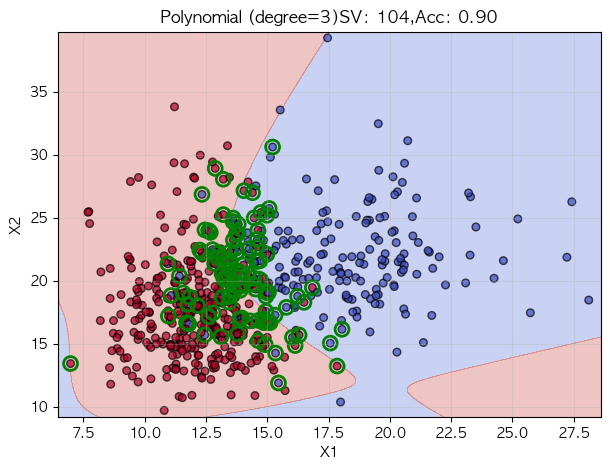

In [ ]:
 # Polynomial Kernel SVM 생성 및 학습
degree = 3
clf_poly = svm.SVC(kernel='poly', degree=degree,  gamma='auto', C=1.0,coef0=1)
clf_poly.fit(X, y)
    
# 결정 경계 그리기
h = .02
x_min = X[:, 0].min() - 0.5
x_max = X[:, 0].max() + 0.5
y_min = X[:, 1].min() - 0.5
y_max = X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),np.arange(y_min, y_max, h))
    
Z = clf_poly.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
    
# 시각화
fig, ax = plt.subplots(figsize=(7,5))
ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
ax.scatter(X[:, 0], X[:, 1],c=y, cmap='coolwarm', s=30, edgecolors='black', alpha=0.7)
    
# Support Vectors 표시
ax.scatter(clf_poly.support_vectors_[:, 0],clf_poly.support_vectors_[:, 1],s=100, facecolors='none', 
              edgecolors='green', linewidths=2)
    
# 제목과 정보
ax.set_title(f'Polynomial (degree={degree})'
            f'SV: {len(clf_poly.support_)},'
            f'Acc: {clf_poly.score(X, y):.2f}')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.grid(True, alpha=0.3)
plt.show()

In [ ]:
print(f"Support Vectors 개수: {len(clf_poly.support_)}")
print(f"Support Vectors 인덱스: {clf_poly.support_[:5]}...")
print(f"Training Accuracy: {clf_poly.score(X, y):.3f}")

Support Vectors 개수: 104
Support Vectors 인덱스: [3 5 7 8 9]...
Training Accuracy: 0.900


In [ ]:
## rbf (가우시안 커널)

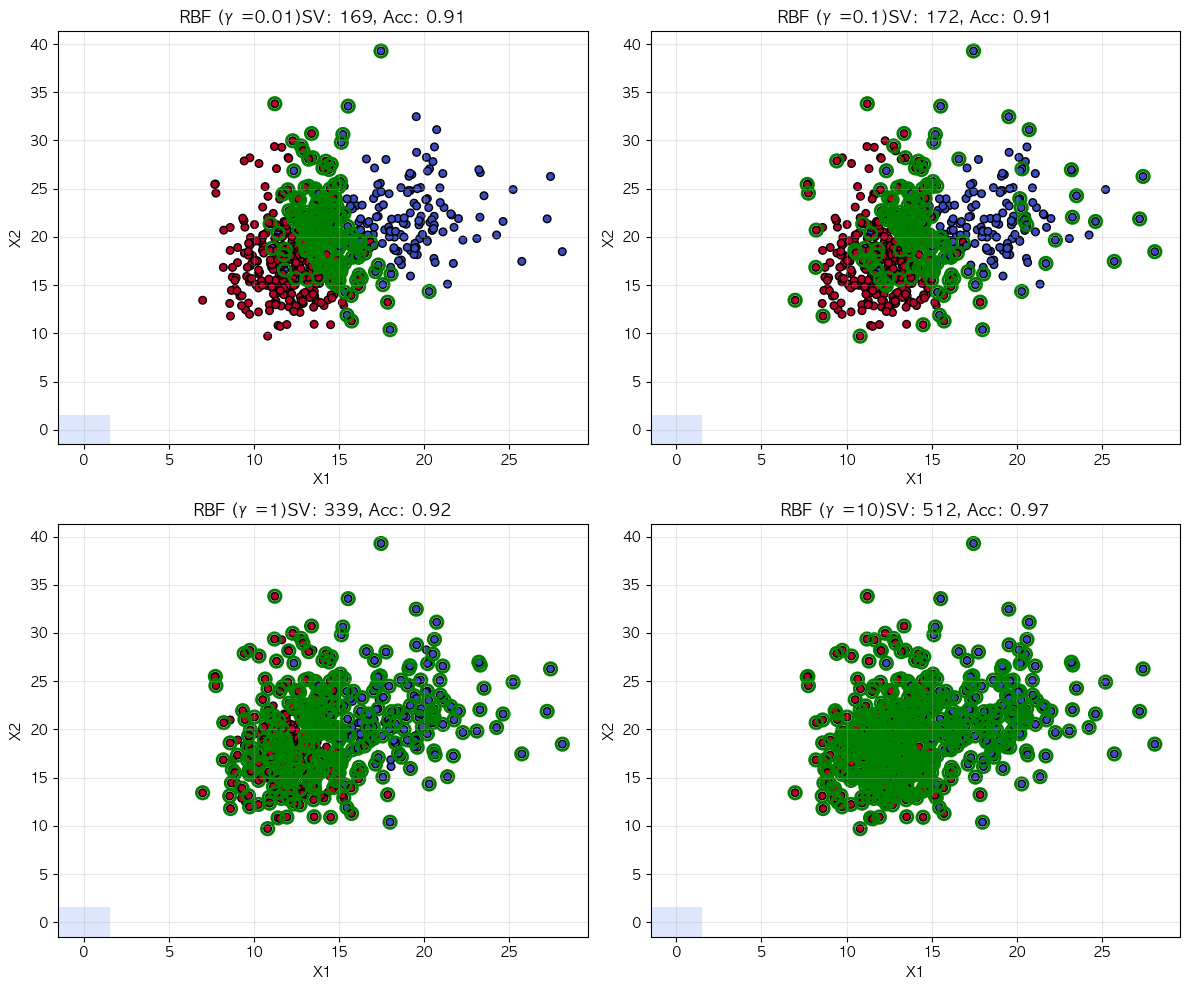

In [ ]:
gamma_values = [0.01, 0.1, 1, 10]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, gamma in enumerate(gamma_values):
    ax = axes[idx // 2, idx % 2]
    
    # RBF Kernel SVM
    clf_rbf = svm.SVC(kernel='rbf', gamma=gamma, C=1.0)
    clf_rbf.fit(X, y)
    
    # 결정 경계
    h = .01
    x_min, x_max = -1.5, 1.5
    y_min, y_max = -1.5, 1.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                        np.arange(y_min, y_max, h))
    
    Z = clf_rbf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # 시각화
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1],c=y, cmap='coolwarm',s=30, edgecolors='black')
    
    # Support Vectors
    ax.scatter(clf_rbf.support_vectors_[:, 0], clf_rbf.support_vectors_[:, 1],
              s=80, facecolors='none', edgecolors='green', linewidths=2)
    
    ax.set_title(f'RBF (γ={gamma})'
                f'SV: {len(clf_rbf.support_)}, '
                f'Acc: {clf_rbf.score(X, y):.2f}')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print(f"Support Vectors 개수: {len(clf_rbf.support_)}")
print(f"Support Vectors 인덱스: {clf_rbf.support_[:5]}...")
print(f"Training Accuracy: {clf_rbf.score(X, y):.3f}")

Support Vectors 개수: 512
Support Vectors 인덱스: [0 1 2 3 4]...
Training Accuracy: 0.968


# 과제 2: 하이퍼파라미터 조정 실험
## rbf 커널을 기준으로 C와 gamma 값을 조정하며 모델의 변화를 관찰하기
### C 값 실험: 0.1, 1, 10
### gamma 값 실험: 0.001, 0.01, 0.1, 1
### 각 조합별 결정 경계 시각화

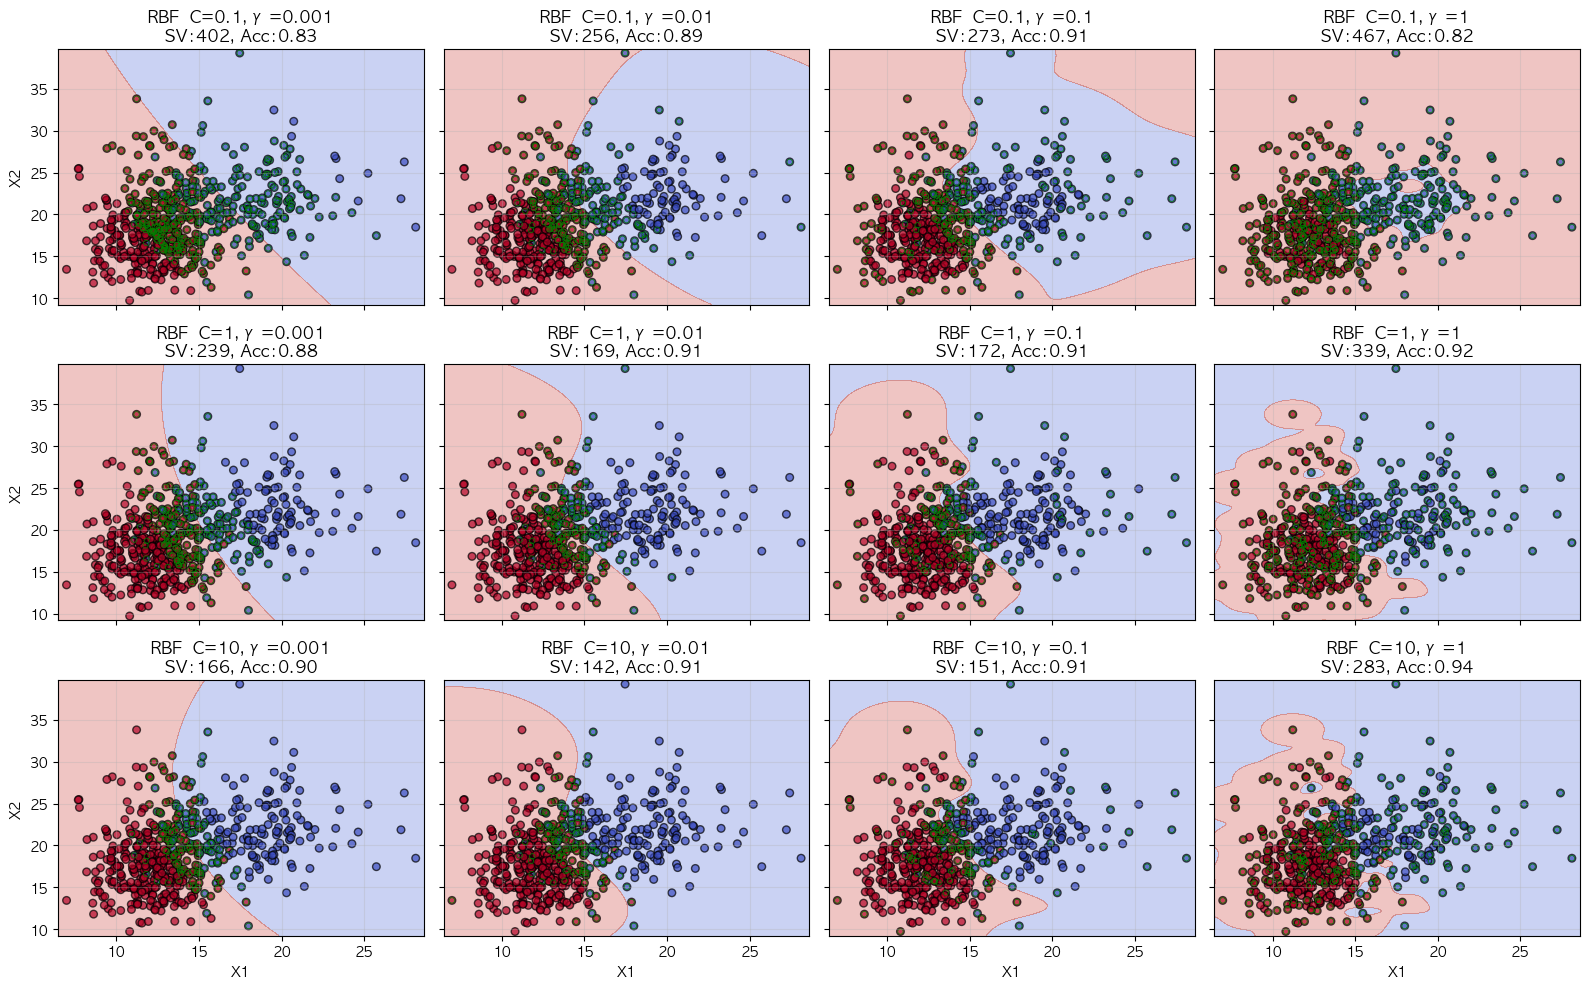

In [166]:
C_values = [0.1, 1, 10] # 클수록 훈련 오류를 더 강하게 억제 → 경계 더 빡빡, 과적합 위험 큼
gamma_values = [0.001, 0.01, 0.1, 1] # RBF의 영향 반경(클수록 매우 국소적·세밀한 경계 → 과적합 위험↑)

# 그리드 범위 (데이터 기준)
h = .01 # 메쉬 간격(해상도). 작을수록 배경이 매끈하지만 계산량↑.
x_min = X[:, 0].min() - 0.5
x_max = X[:, 0].max() + 0.5
y_min = X[:, 1].min() - 0.5
y_max = X[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),np.arange(y_min, y_max, h))
# xx, yy그래프 영역 전체에 촘촘히 깔린 좌표 격자.

fig, axes = plt.subplots(len(C_values), len(gamma_values), figsize=(16, 10), sharex=True, sharey=True)
# 행=|C|, 열=|gamma|
# C_values에 3개 , gamma_values에 4개 총 3x4개의 칸에 각 조합 결과를 그릴 준비
# leg는 보통 Matplotlib에서 legend(범례) 객체를 담아두는 변수 이름을 줄여 쓴 거
# sharex=True → 모든 서브플롯의 x축 한계/눈금이 동일
# sharey=True → 모든 서브플롯의 y축 한계/눈금이 동일
#  (sharex/sharey=True라 축 범위를 통일해서 비교가 쉬움.)

for i, C in enumerate(C_values):
#  enumerate : 반복문에서 인덱스(번호)와 값을 동시에 꺼내주는 파이썬 내장 함수
    for j, gamma in enumerate(gamma_values):
        ax = axes[i, j]
     # 각 조합으로 RBF SVM 모델을 만들고 학습.
        # RBF Kernel SVM
        clf_rbf = svm.SVC(kernel='rbf', gamma=gamma, C=C)
        clf_rbf.fit(X, y)

        # 결정 경계
        Z = clf_rbf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
          # xx.ravel(), yy.ravel() 그리드(2D)를 1D로 펼침.
          # ravel : 배열을 1차원으로 “펼쳐서” 보여주는 NumPy 함수
          # np.c = np.column_stack : 여러 1차원 배열(또는 열 벡터들)을 “열 방향”으로 붙여서 2차원 배열을 만드는 NumPy 함수
          # np.c_[xx.ravel(), yy.ravel()] :두 벡터를 옆으로 붙여 [[x1,y1],[x2,y2],…] 형태의 (N, 2) 입력행렬로 만듦.
          # .reshape(xx.shape) : 예측 결과(1D)를 그리드 모양으로 다시 접어 넣음
          # reshape 해야 plt.contourf나 plt.contour로 결정 경계를 그림.
        
        # 시각화
        ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
        # contourf : 선 사이 영역을 채움/ 등고선(컨투어) 영역을 “색으로 채워서” 그리는 함수예요.
        # contour = 선만 그림

        ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=30, edgecolors='black', marker='o', alpha=0.7)

        # Support Vectors
        ax.scatter(clf_rbf.support_vectors_[:, 0], clf_rbf.support_vectors_[:, 1],
                   s=15, facecolors='none', edgecolors='green', linewidths=0.5)
                   # facecolors는 그래프 객체(점·다각형·패치 등)의 “채움색(면 색)”을 정하는 옵션/속성
        # 제목/축
        acc = clf_rbf.score(X, y)
        ax.set_title(f'RBF  C={C}, γ={gamma}\nSV:{len(clf_rbf.support_)}, Acc:{acc:.2f}')
        if i == len(C_values) - 1:
            ax.set_xlabel('X1')
        if j == 0:
            ax.set_ylabel('X2')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()